![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1 
#libxft 
#mesa-glu
# brew install gcc  

Password:sudo: a password is required
Password:sudo: a password is required
Password:

Run everytime you start to execute this Jupyter Notebook

In [22]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [23]:
from src.upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [24]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

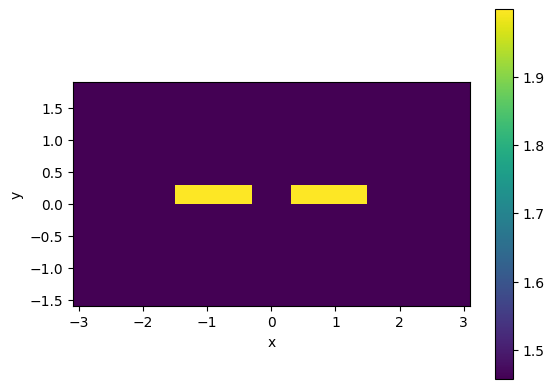

In [25]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index() #diferenciar en como definimos el acoplador ahor atenemos dos regiones de nucleo. 
#si intentamos ver los modos que se propagan por una guia ahor vamos a tener supermodos, podemos obtener el indice efectivo 
# de los modos que s epropaga.
#podemos sacar la fraccion de te y tm , primero prafccion de te muy alt a , 3 y 4 modo tm .
#si hacemos los plots vemos una estructura mas compleja, se representa el campo ey variacion en horizontal,
#vemos en los dos casos un campo positivo, sera el tepar. el 1 parte positiva y negativa estan encontrafase , 
# variacion en horizontal , modo te 
# modos tm campo en y variacione n vertical modos tm modo par , modo 3 vemos el modo impar , a diferencia de la 
# anterior cemos supermodos que se propagan por esta estructura mas compleja.
#ahora calculamos la alongitud de acolplo para ver con que longitud se acopla de una guia a otra. 
# vemos los modos par e u¡impar de los modo te y tm .
# decoupler_cs(coupling length), para saber la alogitud de acoplo hacemos un barrido. 

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [26]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-04-30 13:26:47.062 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [27]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [28]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

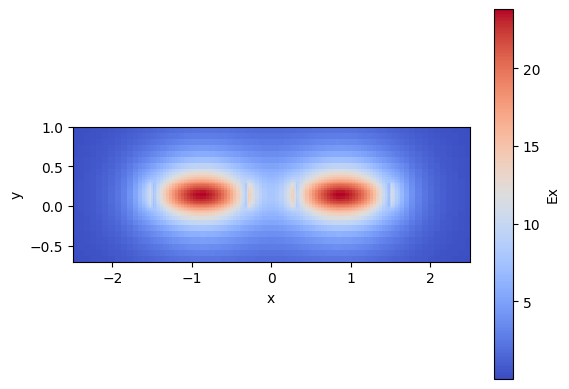

In [29]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

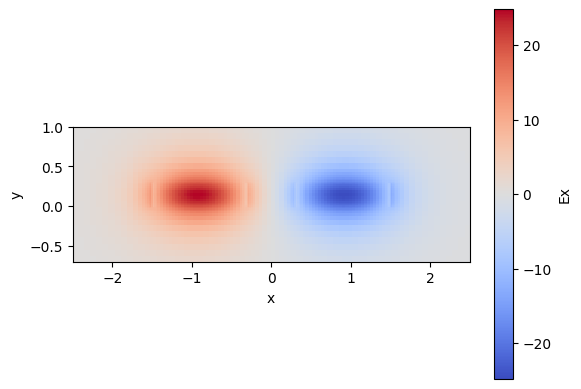

In [30]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

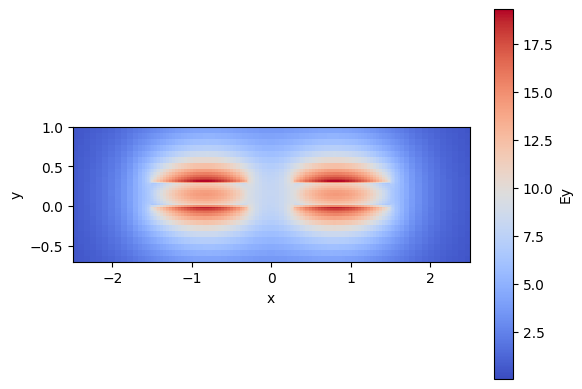

In [31]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

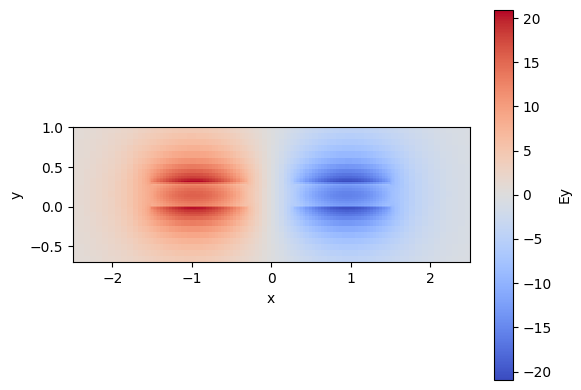

In [32]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [33]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536698734
52.2602236774375


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [34]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/var/folders/1g/mvwfd37x1vj3xxvvqrdby2y40000gn/T/ipykernel_14947/4082249134.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Power Coupling vs. Normalized Length ($L/L_{\pi}$)")
/var/folders/1g/mvwfd37x1vj3xxvvqrdby2y40000gn/T/ipykernel_14947/4082249134.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Normalized Length ($L/L_{\pi}$)")
/var/folders/1g/mvwfd37x1vj3xxvvqrdby2y40000gn/T/ipykernel_14947/4082249134.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


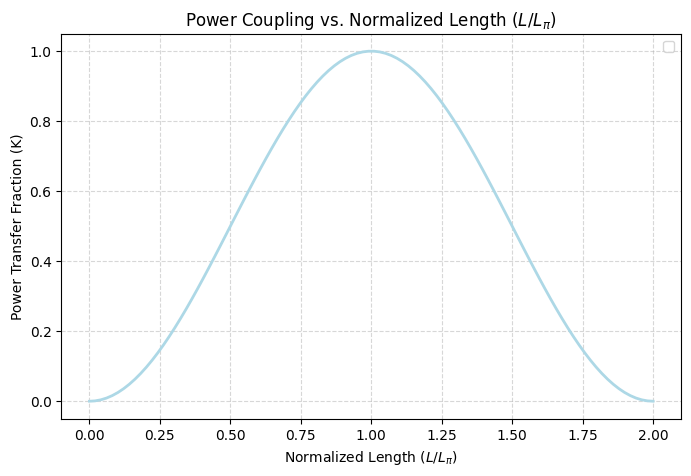

In [35]:
#se pide que veamos la variacion de la logittud de acoplo dependiendo de la longitud del acoplador, para eso hacemos un barrido de la longitud del acoplador y vemos como varia la fraccion de potencia que se acopla a la guia adyacente.
#relacionarlo con lacte de acoplo
import numpy as np
import matplotlib.pyplot as plt

LL_pi = np.linspace(0, 2, 100)

k = np.sin((np.pi * LL_pi) / 2)**2

plt.figure(figsize=(8, 5))
plt.plot(LL_pi, k, color='lightblue', linewidth=2)
plt.title("Power Coupling vs. Normalized Length ($L/L_{\pi}$)")
plt.xlabel("Normalized Length ($L/L_{\pi}$)")
plt.ylabel("Power Transfer Fraction (K)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#cuado l vale 1 es acoplamiento totoal a pasadoa la otra guia cuando es 0 no ha pasado nada 



## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [36]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here

wg_gap = 1.2 # Student. Gap between waveguides #0.2,0.4,0.6---->1.2
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

#ahora vamos simular esa propagar, y vemos como se va acoplando de una guia a otra

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  580.4291411412886  µm


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


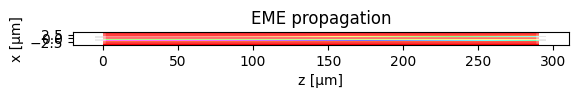

In [37]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
# wg_gap = 0.2 

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


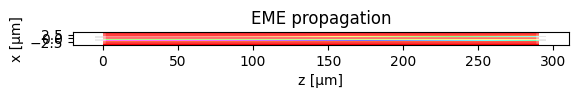

In [38]:
# wg_gap = 0.4
#  3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


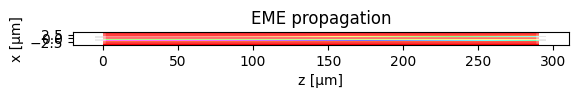

In [39]:
# wg_gap = 0.6
#  3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


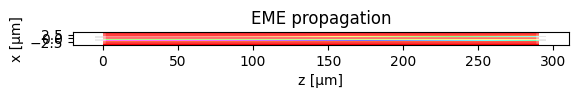

In [40]:
# wg_gap = 0.8
#  3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


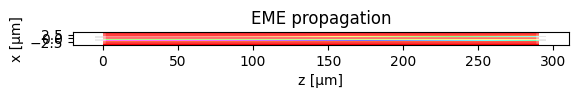

In [41]:
# wg_gap = 1.0
#  3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


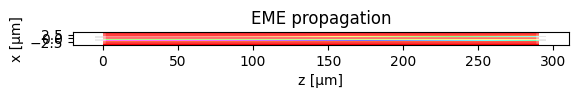

In [42]:
# wg_gap = 1.2
#  3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



  0%|          | 0/20 [00:00<?, ?it/s]

2026-04-30 13:37:19.120 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1c3779823ede9330.npz.
2026-04-30 13:37:19.132 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_caa3cfbbdd1ba556.npz.
2026-04-30 13:37:19.134 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a1faec2966a5c4d4.npz.
2026-04-30 13:37:19.136 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_db86fa9995e0912f.npz.
2026-04-30 13:37:19.137 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e604699711b3b598.npz.
2026-04-30 13:37:19.138 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_866c9b2e0265053a.npz.
2026-04-30 13:37:19.141 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_87b243d2d81c7c8b.npz.
2026-04-30 13:37:19.144 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

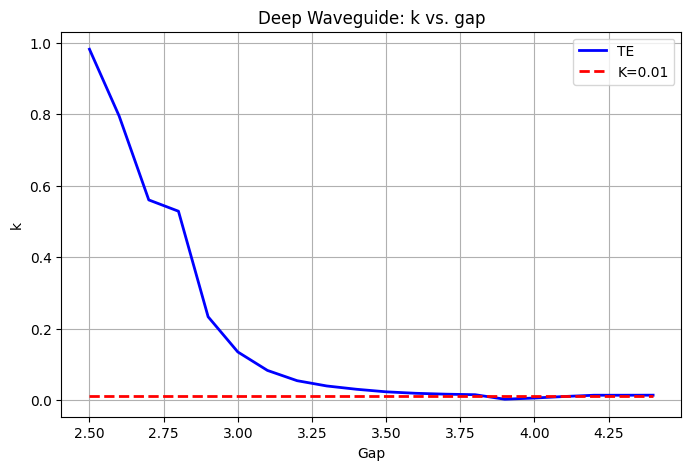

In [53]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
# calcular la lpi para esta estructura y mantener la contante de acopo por dejbajo de 0,01 y
# hacer una barrido para ver cuando se satisfce esa condicion.
L = 10000  # Longitud de interacción en micras
lambda_c = 1.55              # Longitud de onda de operación (um)
# deep waveguide 
dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1, 1), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap = 2.5,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=3, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

gaps = np.arange(2.5, 4.5, 0.1)

result = gt.modes.sweep_coupling_length(dcoupler_cs,gaps)
#print(result)

k= np.sin((np.pi * (L / result) )/ 2)**2
#print(k)

plt.figure(figsize=(8, 5))
plt.plot(gaps, k, 'b-', linewidth=2, label='TE')
plt.plot(gaps, 0.01 * np.ones_like(gaps), 'r--', linewidth=2, label='K=0.01')
plt.title("Deep Waveguide: k vs. gap")
plt.xlabel("Gap")
plt.ylabel("k")
plt.grid()
plt.legend()
plt.show()



  0%|          | 0/20 [00:00<?, ?it/s]

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-30 13:40:36.202 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e6931453b31ee1cf.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-30 13:40:37.602 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_ae7387aa73a3b1b5.npz.


...

2026-04-30 13:41:00.260 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_a7028b2ea3a7ff87.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-30 13:41:01.845 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_2301106951863433.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-30 13:41:03.435 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_0ac9a9e9a1f7d464.npz.


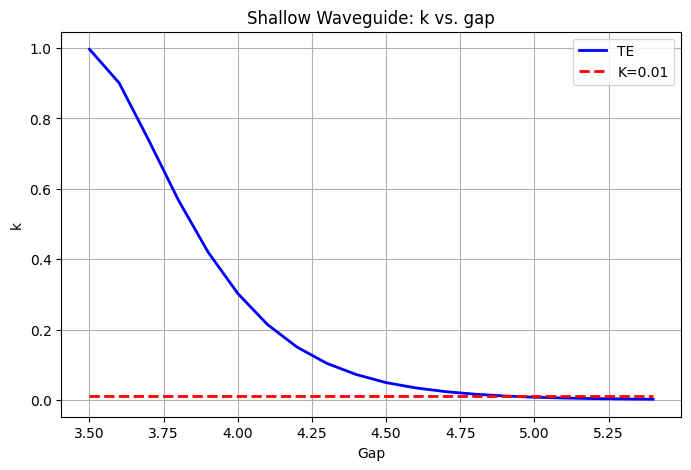

In [55]:
L = 10000  # Longitud de interacción en micras
lambda_c = 1.55              # Longitud de onda de operación (um)
# shallow waveguide 
shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1, 1), # Waveguide width
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap = 2.5,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=3, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

gaps = np.arange(3.5, 5.5, 0.1) 

result = gt.modes.sweep_coupling_length(shallow_dcoupler_cs,gaps)
#print(result)

k= np.sin(0.5*np.pi *(L / (result)))**2
#print(k)

plt.figure(figsize=(8, 5))
plt.plot(gaps, k, 'b-', linewidth=2, label='TE')
plt.plot(gaps, 0.01 * np.ones_like(gaps), 'r--', linewidth=2, label='K=0.01')
plt.title("Shallow Waveguide: k vs. gap")
plt.xlabel("Gap")
plt.ylabel("k")
plt.grid()
plt.legend()
plt.show()



## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [29]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

13:00:40 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-24 13:00:40.886 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [30]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

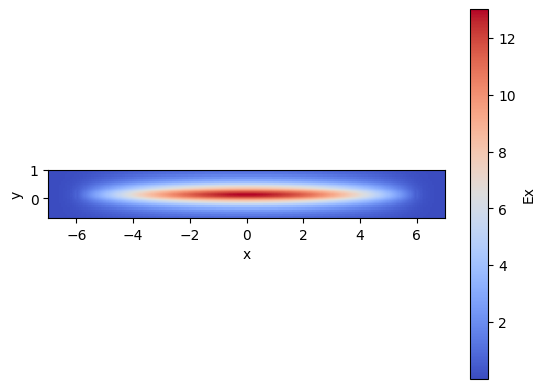

In [31]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

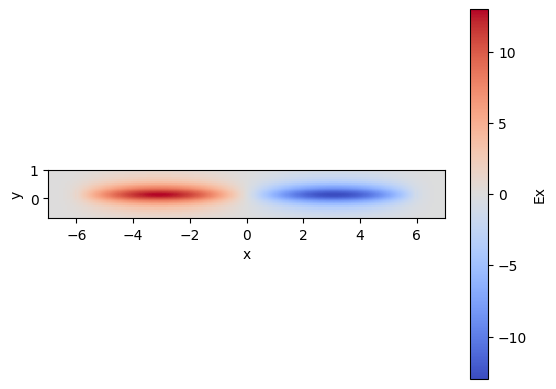

In [32]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

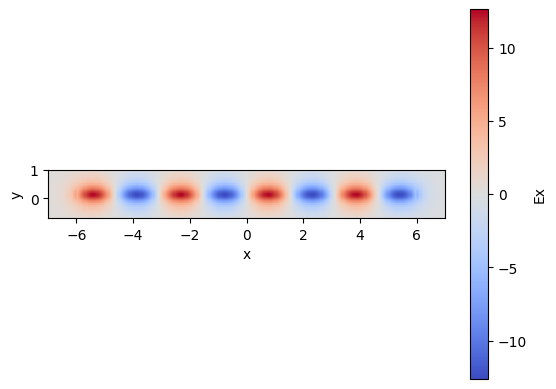

In [33]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [34]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794417114


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [35]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03590455329076  µm


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9602
Total OUT power: 0.9073
Excess loss [dB] =  0.4225
------------------------
Power over OUTs:  ['0.4673', '0.4400']
Ratio over OUTs ['0.5151', '0.4849']


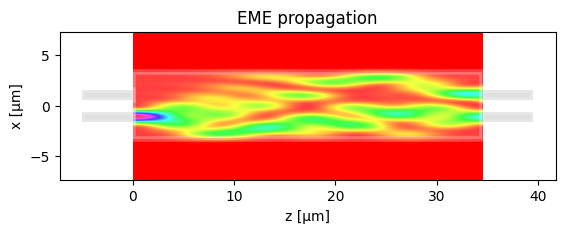

In [36]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/689 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.0500
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9686
Total OUT power: 0.9361
Excess loss [dB] =  0.2868
------------------------
Power over OUTs:  ['0.4802', '0.4559']
Ratio over OUTs ['0.5129', '0.4871']


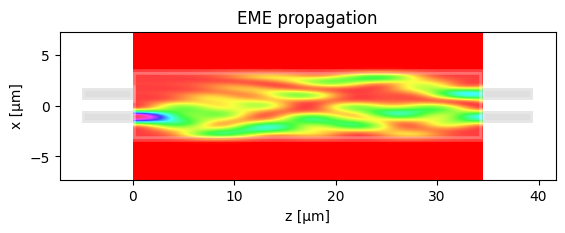

In [74]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.05 # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [86]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.8 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03590455328258  µm


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/694 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.2000
IO wg width 1.0000
IO wg width increment 0.8000
------------------------
Total power IN coupled 0.9938
Total OUT power: 0.9790
Excess loss [dB] =  0.0923
------------------------
Power over OUTs:  ['0.4953', '0.4837']
Ratio over OUTs ['0.5059', '0.4941']


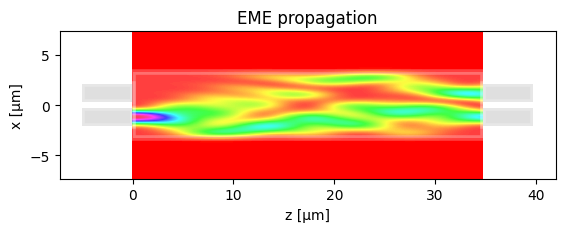

In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = 0.2 # STUDENT


# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [114]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 12  # MMI width
m.wg_width_dw = 1.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13985375817688  µm


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/820 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0887
MMI length increment -0.1000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 0.9971
Total OUT power: 0.9880
Excess loss [dB] =  0.0523
------------------------
Power over OUTs:  ['0.2411', '0.2529', '0.2529', '0.2411']
Ratio over OUTs ['0.2440', '0.2560', '0.2560', '0.2440']


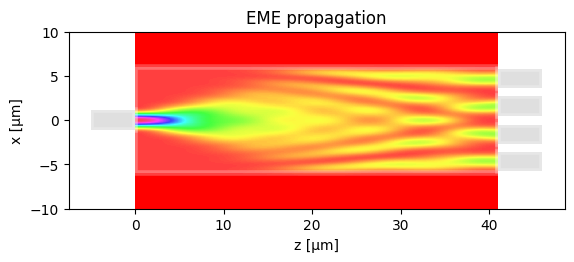

In [138]:

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.5
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/6,-1/6,1/6,3/6]) + np.array([-1.4,-dy,dy,1.4])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi  # STUDENT
m.dL_MMI = -0.1 # STUDENT


# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

  0%|          | 0/12 [00:00<?, ?it/s]

2026-04-29 11:00:51.488 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-04-29 11:00:51.495 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
2026-04-29 11:00:51.497 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
2026-04-29 11:00:51.499 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
2026-04-29 11:00:51.501 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
2026-04-29 11:00:51.503 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_675ac575bd9f8480.npz.
2026-04-29 11:00:51.506 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_69d8430ee5b848c9.npz.
2026-04-29 11:00:51.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

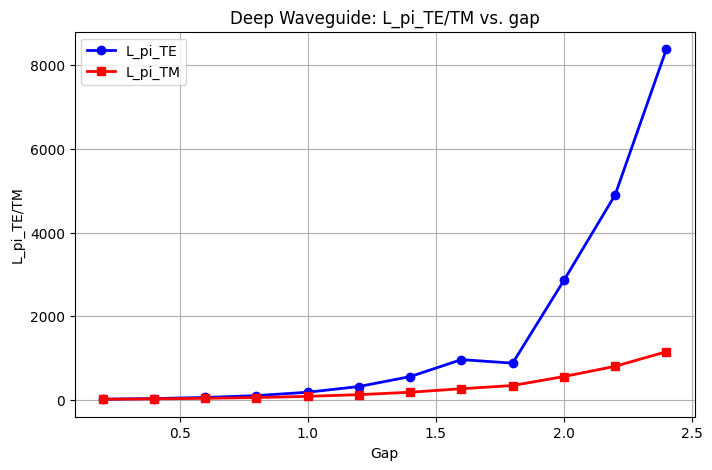

In [21]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

gap_range = np.arange(0.2, 2.6, 0.2)
wavelength = 1550 * nm


deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)


result = gt.modes.sweep_coupling_length(deep_dcoupler_cs,gaps=gap_range)
print(result)
# Extraer columnas
Lpi_TE = result[:, 0]  # columna 0 → TE
Lpi_TM = result[:, 1]  # columna 1 → TM

plt.figure(figsize=(8, 5))
plt.plot(gap_range, Lpi_TE, 'b-o', linewidth=2, label='L_pi_TE')
plt.plot(gap_range, Lpi_TM, 'r-s',linewidth=2, label='L_pi_TM')
plt.title("Deep Waveguide: L_pi_TE/TM vs. gap")
plt.xlabel("Gap")
plt.ylabel("L_pi_TE/TM")
plt.grid()
plt.legend()
plt.show()



  0%|          | 0/12 [00:00<?, ?it/s]

2026-04-29 10:59:31.734 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8c8eb63846dcafc2.npz.
2026-04-29 10:59:31.752 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9f55a49562c957ac.npz.
2026-04-29 10:59:31.757 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0aace39711989615.npz.
2026-04-29 10:59:31.758 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_469dd463acb1cce2.npz.
2026-04-29 10:59:31.760 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_12053cc304837a1c.npz.
2026-04-29 10:59:31.761 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_268a018761ef6ebf.npz.
2026-04-29 10:59:31.763 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9664102640d36134.npz.
2026-04-29 10:59:31.765 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

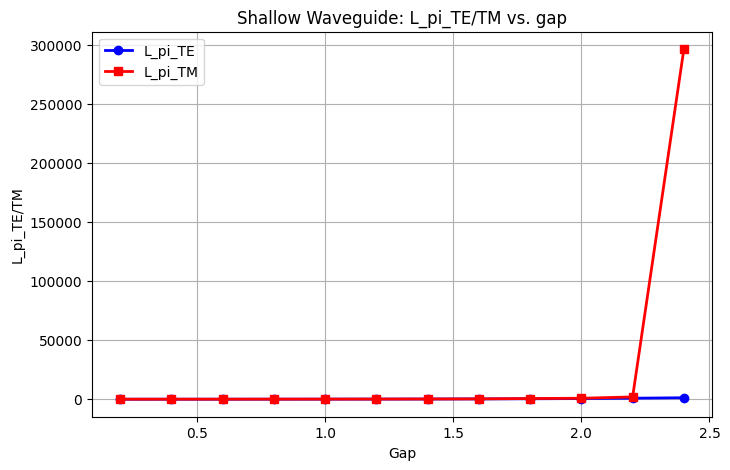

In [ ]:
#shallow waveguide

gap_range = np.arange(0.2, 2.6, 0.2)
wavelength = 1550 * nm
gap_to_simulate = 600 * nm 

shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)


result = gt.modes.sweep_coupling_length(shallow_dcoupler_cs,gaps=gap_range)
print(result)
# Extraer columnas
Lpi_TE = result[:, 0]  # columna 0 → TE
Lpi_TM = result[:, 1]  # columna 1 → TM

plt.figure(figsize=(8, 5))
plt.plot(gap_range, Lpi_TE, 'b-o', linewidth=2, label='L_pi_TE')
plt.plot(gap_range, Lpi_TM, 'r-s',linewidth=2, label='L_pi_TM')
plt.title("Shallow Waveguide: L_pi_TE/TM vs. gap")
plt.xlabel("Gap")
plt.ylabel("L_pi_TE/TM")
plt.grid()
plt.legend()
plt.show()



### E2. Directional coupler wavelength dependence

2026-04-30 13:25:51.071 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ac66cce45f10ccae.npz.


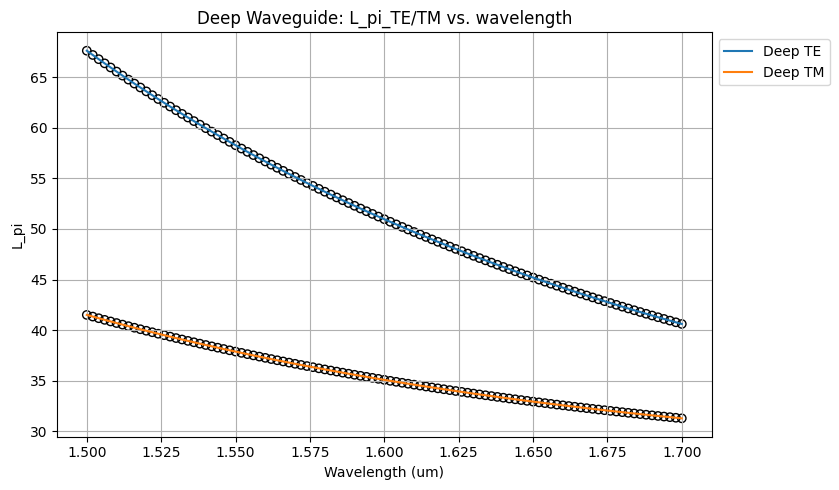

In [11]:
wavelength = np.linspace(1500, 1700, 101) * nm # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

neff = deep_dcoupler_cs.n_eff
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*wavelength/(neff[:,0].real-neff[:,1].real)
L_pi_TM = 0.5*wavelength/(neff[:,2].real-neff[:,3].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep TE')
plt.scatter(wavelength, L_pi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TM,label='Deep TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.title("Deep Waveguide: L_pi_TE/TM vs. wavelength")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

2026-04-30 13:25:53.762 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_51a919f14500c45e.npz.


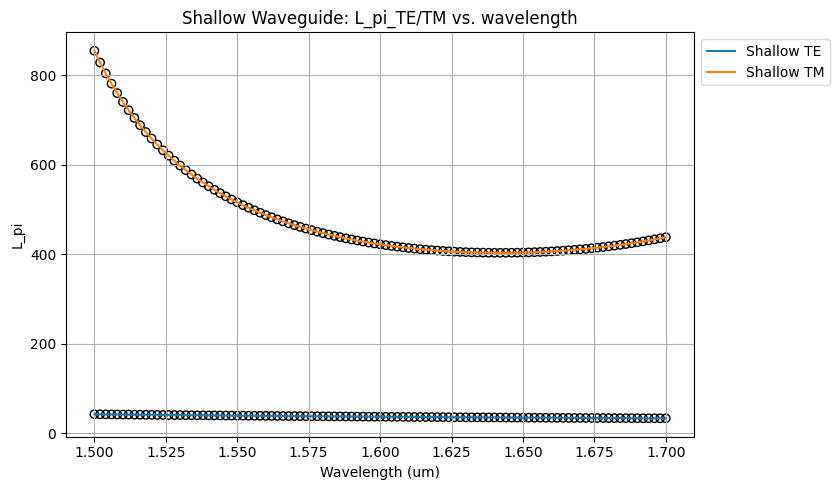

In [12]:
#shallow
wavelength = np.linspace(1500, 1700, 101) * nm # STUDENT code goes here

shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

neff = shallow_dcoupler_cs.n_eff
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*wavelength/(neff[:,0].real-neff[:,1].real)
L_pi_TM = 0.5*wavelength/(neff[:,2].real-neff[:,3].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Shallow TE')
plt.scatter(wavelength, L_pi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TM,label='Shallow TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.title("Shallow Waveguide: L_pi_TE/TM vs. wavelength")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [13]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1500, 1700, 101)*nm # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)


In [14]:
 
neff = mmi_body_waveguide.n_eff




2026-04-30 13:25:59.389 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_23c9c03a7ba8e46a.npz.


In [15]:
d_n_eff_TE = neff[:,0].real - neff[:,1].real
d_n_eff_TM = neff[:,2].real -  neff[:,3].real

#L_pi = wavelength / (2 * d_n_eff)   # STUDENT code goes here
L_pi_TE = 0.5*wavelength/d_n_eff_TE
L_pi_TM = 0.5*wavelength/d_n_eff_TM

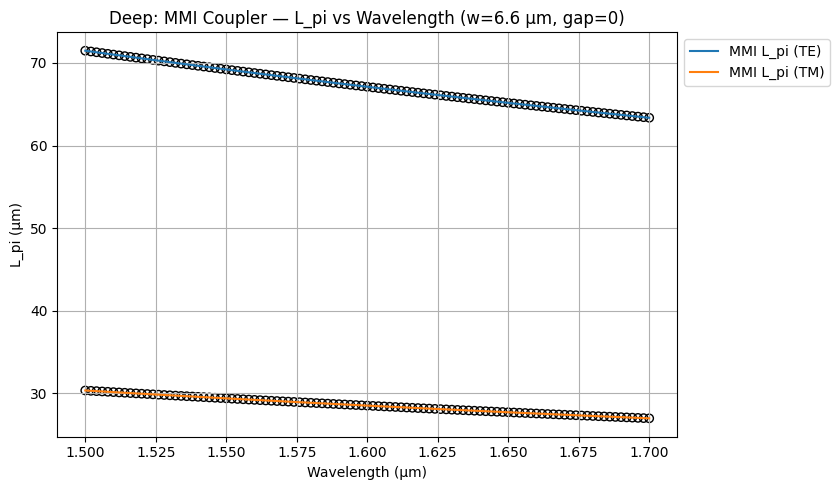

In [16]:
# STUDENT plot here. 
plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='MMI L_pi (TE)')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TM, label='MMI L_pi (TM)')
plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Deep: MMI Coupler — L_pi vs Wavelength (w=6.6 µm, gap=0)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [58]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1500, 1700, 101)*nm # STUDENT code goes here.

mmi_body_waveguide_shallow = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)


In [59]:
neff = mmi_body_waveguide_shallow.n_eff

2026-04-30 13:42:37.301 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4f9188a035524580.npz.


KeyError: 'n_eff is not a file in the archive'

In [19]:
d_n_eff_TE = neff[0].real - neff[1].real
d_n_eff_TM = neff[2].real -  neff[3].real

#L_pi = wavelength / (2 * d_n_eff)   # STUDENT code goes here
L_pi_TE = 0.5*wavelength/d_n_eff_TE
L_pi_TM = 0.5*wavelength/d_n_eff_TM

# STUDENT plot here. 
plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k')
plt.plot(wavelength, L_pi_TE, label='MMI L_pi (TE)')
plt.scatter(wavelength, L_pi_TM, edgecolors='k')
plt.plot(wavelength, L_pi_TM, label='MMI L_pi (TM)')
plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Shallow: MMI Coupler — L_pi vs Wavelength (w=6.6 µm, gap=0)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

ValueError: operands could not be broadcast together with shapes (101,) (15,) 

### E4. MMI coupler body width dependence

In [34]:
lambda_c = 1.55

width_range = np.arange(5.0, 10.5, 0.5)

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 
Lpi_TE = []
Lpi_TM = []

for mmi_body_w in width_range:
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    d_n_eff_TE = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real
    d_n_eff_TM = mmi_body_waveguide.n_eff[2].real -  mmi_body_waveguide.n_eff[3].real

    Lpi_TE.append(0.5*lambda_c/d_n_eff_TE)

    Lpi_TM.append(0.5*lambda_c/d_n_eff_TM)

Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

2026-04-29 13:10:19.650 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_750afcc7e2a92dbc.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

13:10:21 CEST WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

...

2026-04-29 13:10:35.578 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_09f64d33f8d29b19.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-29 13:10:37.630 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_cb827f9f108742e4.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

2026-04-29 13:10:39.780 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0715b5214f4328e7.npz.


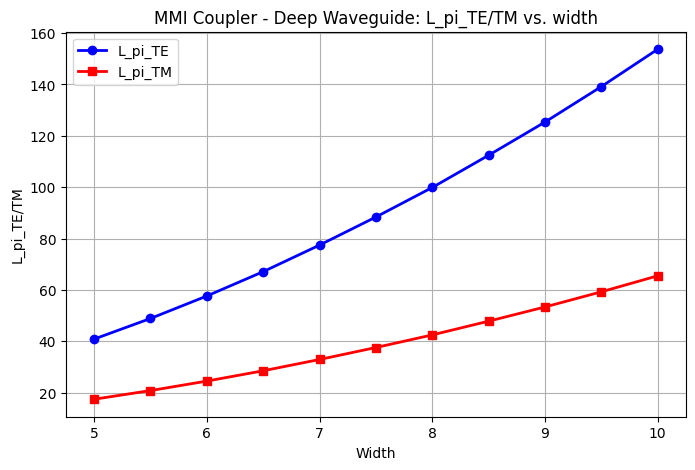

In [35]:

plt.figure(figsize=(8, 5))
plt.plot(width_range, Lpi_TE, 'b-o', linewidth=2, label='L_pi_TE')
plt.plot(width_range, Lpi_TM, 'r-s',linewidth=2, label='L_pi_TM')
plt.title("MMI Coupler - Deep Waveguide: L_pi_TE/TM vs. width")
plt.xlabel("Width")
plt.ylabel("L_pi_TE/TM")
plt.grid()
plt.legend()
plt.show()

/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

13:13:14 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

...

13:13:32 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-04-29 13:13:32.668 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4e080f8573a04258.npz.


/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/Users/claudia/Desktop/CIFOIN/cifoin-lab2/.venv/lib/python3

13:13:34 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-04-29 13:13:34.972 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_17e36e7035c1827e.npz.


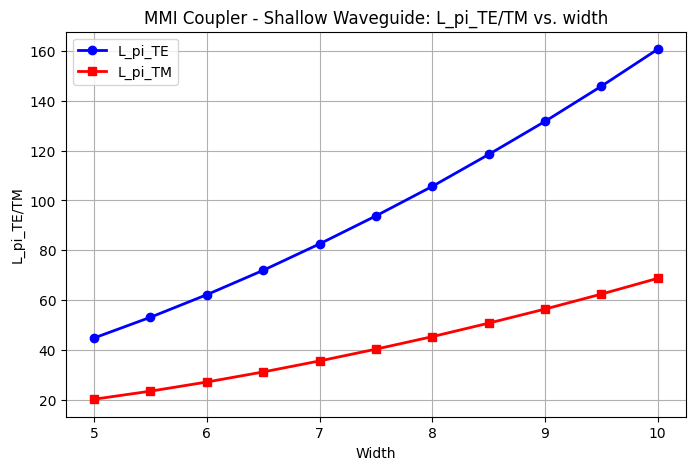

In [36]:
lambda_c = 1.55

width_range = np.arange(5.0, 10.5, 0.5)

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 
Lpi_TE = []
Lpi_TM = []

for mmi_body_w in width_range:
    mmi_body_waveguide_shallow = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    d_n_eff_TE = mmi_body_waveguide_shallow.n_eff[0].real -  mmi_body_waveguide_shallow.n_eff[1].real
    d_n_eff_TM = mmi_body_waveguide_shallow.n_eff[2].real -  mmi_body_waveguide_shallow.n_eff[3].real

    Lpi_TE.append(0.5*lambda_c/d_n_eff_TE)

    Lpi_TM.append(0.5*lambda_c/d_n_eff_TM)

Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)
plt.figure(figsize=(8, 5))
plt.plot(width_range, Lpi_TE, 'b-o', linewidth=2, label='L_pi_TE')
plt.plot(width_range, Lpi_TM, 'r-s',linewidth=2, label='L_pi_TM')
plt.title("MMI Coupler - Shallow Waveguide: L_pi_TE/TM vs. width")
plt.xlabel("Width")
plt.ylabel("L_pi_TE/TM")
plt.grid()
plt.legend()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points